# Playground for weather data
Check [this](https://prism.oregonstate.edu/data/) out.

In [ ]:
from pathlib import Path
from datetime import date, timedelta
import time
import requests

START_DATE = date(2025, 1, 1)
END_DATE = date(2025, 12, 31)

RESOLUTION = "4km"
VARIABLE = "tmean"

download_dir = Path("data/prism/tmean_daily_2025")
download_dir.mkdir(parents=True, exist_ok=True)

base_url = (
    "https://services.nacse.org/prism/data/get/"
    f"us/{RESOLUTION}/{VARIABLE}"
)

session = requests.Session()

current_date = START_DATE

while current_date <= END_DATE:
    date_string = current_date.strftime("%Y%m%d")
    output_path = download_dir / f"prism_tmean_us_4km_{date_string}.zip"

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Already downloaded: {date_string}")
        current_date += timedelta(days=1)
        continue

    url = f"{base_url}/{date_string}"

    try:
        response = session.get(
            url,
            timeout=120,
        )
        response.raise_for_status()

        output_path.write_bytes(response.content)

        print(
            f"Downloaded {date_string}: "
            f"{output_path.stat().st_size / 1_000_000:.1f} MB"
        )

    except requests.RequestException as error:
        print(f"Failed {date_string}: {error}")

    time.sleep(2)
    current_date += timedelta(days=1)

Already downloaded: 20250101
Already downloaded: 20250102
Already downloaded: 20250103
Already downloaded: 20250104
Already downloaded: 20250105
Already downloaded: 20250106
Already downloaded: 20250107
Already downloaded: 20250108
Already downloaded: 20250109
Already downloaded: 20250110
Already downloaded: 20250111
Already downloaded: 20250112
Already downloaded: 20250113
Already downloaded: 20250114
Already downloaded: 20250115
Already downloaded: 20250116
Already downloaded: 20250117
Already downloaded: 20250118
Already downloaded: 20250119
Already downloaded: 20250120
Already downloaded: 20250121
Already downloaded: 20250122
Already downloaded: 20250123
Already downloaded: 20250124
Already downloaded: 20250125
Already downloaded: 20250126
Already downloaded: 20250127
Already downloaded: 20250128
Already downloaded: 20250129
Already downloaded: 20250130
Already downloaded: 20250131
Already downloaded: 20250201
Already downloaded: 20250202
Already downloaded: 20250203
Already downlo

In [2]:
import zipfile

invalid_files = []

for zip_path in sorted(download_dir.glob("*.zip")):
    if not zipfile.is_zipfile(zip_path):
        invalid_files.append(zip_path)
        print(f"Invalid ZIP: {zip_path.name}")

print(f"Valid ZIPs: {len(list(download_dir.glob('*.zip'))) - len(invalid_files)}")
print(f"Invalid ZIPs: {len(invalid_files)}")

Valid ZIPs: 115
Invalid ZIPs: 0


In [3]:
raster_dir = Path("data/prism/tmean_daily_2025_tif")
raster_dir.mkdir(parents=True, exist_ok=True)

for zip_path in sorted(download_dir.glob("*.zip")):
    if not zipfile.is_zipfile(zip_path):
        continue

    with zipfile.ZipFile(zip_path) as archive:
        tif_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith(".tif")
        ]

        if len(tif_members) != 1:
            print(
                f"Unexpected number of TIFF files in "
                f"{zip_path.name}: {len(tif_members)}"
            )
            continue

        member = tif_members[0]
        target = raster_dir / Path(member).name

        if not target.exists():
            with archive.open(member) as source:
                target.write_bytes(source.read())

In [31]:
import rasterio
import rasterio.features

tif_files = sorted(raster_dir.glob("*.tif"))
first_raster = tif_files[0]

with rasterio.open(first_raster) as src:
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Data type:", src.dtypes)
    print("Tags:", src.tags())

    print("Stats:", src.stats())

    # Read the dataset's valid data mask as a ndarray.
    mask = src.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=src.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        geom = rasterio.warp.transform_geom(
            src.crs, 'EPSG:4326', geom, precision=6)

        # Print GeoJSON shapes to stdout.
        # print(geom)

CRS: EPSG:4269
Shape: (621, 1405)
Resolution: (0.041666666667, 0.041666666667)
NoData: -9999.0
Bounds: BoundingBox(left=-125.0208333333335, bottom=24.062499999793495, right=-66.4791666661985, top=49.9375000000005)
Data type: ('float32',)
Tags: {'PRISM_CODE_VERSION': '16.1-20230816-1307', 'PRISM_DATASET_CREATE_DATE': '20250715', 'PRISM_DATASET_FILENAME': 'cai_tmax_us_us_30s_20250101.bil, cai_tmin_us_us_30s_20250101.bil', 'PRISM_DATASET_RELEASE_NUMBER': '8', 'PRISM_DATASET_REMARKS': 'This grid was developed in three steps:  (1) tmin and tmax were initially modeled with PRISM at 30-arc-second (~800-m) resolution to produce the source grids listed under PRISM_DATASET_FILENAME, on the date(s) listed under PRISM_DATASET_CREATE_DATE; (2) these 800-m tmin and tmax grids were upscaled to 2.5-arc-minute (~4-km) resolution with a Gaussian filter; and (3) the resulting 4-km tmin and tmax grids were averaged to obtain a 4-km mean temperature grid.', 'PRISM_DATASET_TYPE': 'an91/r2112', 'PRISM_DATASE

In [45]:
import numpy as np
import geopandas as gpd
import rasterio

from shapely.geometry import box
from rasterio.windows import Window, bounds

# with rasterio.open(first_raster) as src:
with rasterio.open("data/prism/tmean_daily_2025_tif/prism_tmean_us_25m_20250401.tif") as src:
    data = src.read(1, masked=True)

    rows, cols = np.where(~np.ma.getmaskarray(data))

    polygons = [
        box(*bounds(Window(col, row, 1, 1), src.transform))
        for row, col in zip(rows, cols)
    ]

    sample = gpd.GeoDataFrame(
        {
            "ROW": rows,
            "COL": cols,
            "TMEAN": data.data[rows, cols],
        },
        geometry=polygons,
        crs=src.crs,
    )

sample.head()

,ROW,COL,TMEAN,geometry
0,12,717,-3.01300,"POLYGON ((-95.10417 49.39583, -95.10417 49.437..."
1,13,716,-2.88555,"POLYGON ((-95.14583 49.35417, -95.14583 49.395..."
2,13,717,-3.03085,"POLYGON ((-95.10417 49.35417, -95.10417 49.395..."
3,13,718,-3.18150,"POLYGON ((-95.0625 49.35417, -95.0625 49.39583..."
4,13,719,-3.14285,"POLYGON ((-95.02083 49.35417, -95.02083 49.395..."


<Axes: >

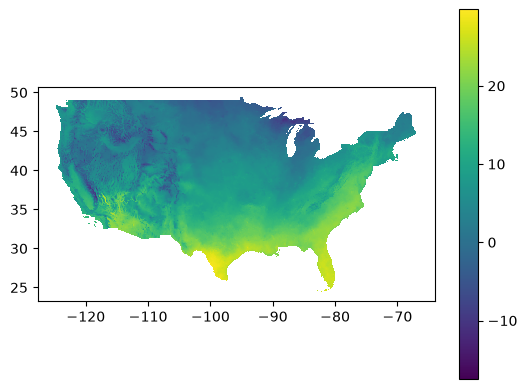

In [46]:
sample.plot(column="TMEAN", legend=True)